Chapter 3 - Methods

Section 3.4.2: Establishing a burn-in Time

Looking at RNA mass trajectories to determine an appropriate burn-in time accross nutrient and antibiotic conditions to remove initial transient dynamics during stochastic simulation initialization.

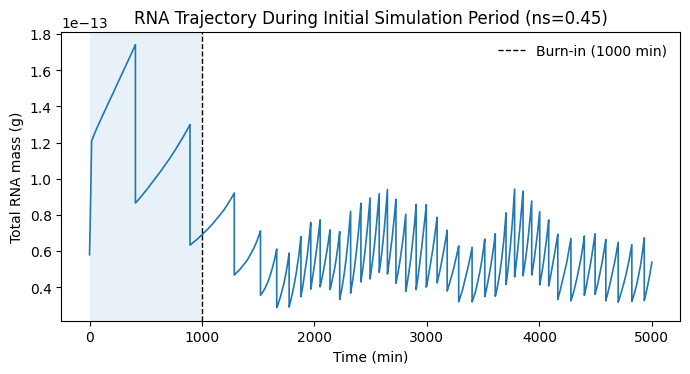

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

ARROW_FILE = "../Data/ns045/abx0.arrow"

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

MW_NT = 330.0          # g/mol
NA = 6.022e23          # Avogadro

BURN_IN = 1000         # min
TIME_LIMIT = 5000      # min

plt.style.use("default")


def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

df = load_arrow(ARROW_FILE)


def compute_rna_mass(df):

    # mRNA nucleotides
    NmRNA = (
        (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX) +
        (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX) +
        (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX) +
        (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)
    ).to_numpy()

    # total ribosome count
    Nribo = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    # rRNA nucleotides
    NrRNA = Nribo * RIBO_RNA_NT

    # total RNA mass (grams)
    RNA_mass = (NmRNA + NrRNA) / NA * MW_NT

    return RNA_mass

df["RNA_mass_g"] = compute_rna_mass(df)

df_plot = df[df["timestamp"] <= TIME_LIMIT]

plt.figure(figsize=(7,4))

plt.plot(
    df_plot["timestamp"],
    df_plot["RNA_mass_g"],
    linewidth=1.2
)

plt.axvspan(
    0,
    BURN_IN,
    alpha=0.1
)

plt.axvline(
    x=BURN_IN,
    linestyle="--",
    linewidth=1,
    color="black",
    label="Burn-in (1000 min)"
)

plt.xlabel("Time (min)")
plt.ylabel("Total RNA mass (g)")
plt.title("RNA Trajectory During Initial Simulation Period (ns=0.45)")

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

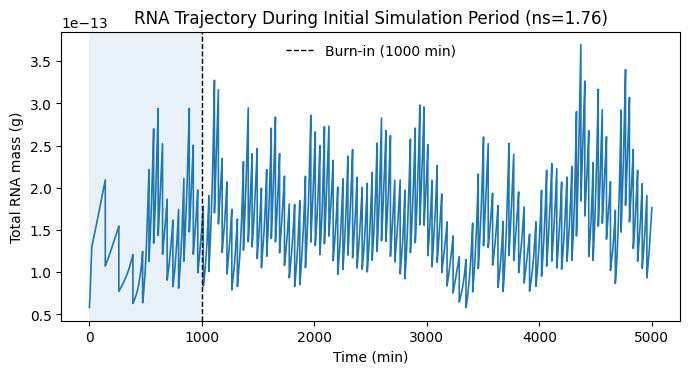

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

ARROW_FILE = "../Data/ns176/abx0.arrow"

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

MW_NT = 330.0          # g/mol
NA = 6.022e23          # Avogadro

BURN_IN = 1000         # min
TIME_LIMIT = 5000      # min

plt.style.use("default")


def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

df = load_arrow(ARROW_FILE)


def compute_rna_mass(df):

    # mRNA nucleotides
    NmRNA = (
        (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX) +
        (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX) +
        (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX) +
        (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)
    ).to_numpy()

    # total ribosome count
    Nribo = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    # rRNA nucleotides
    NrRNA = Nribo * RIBO_RNA_NT

    # total RNA mass (grams)
    RNA_mass = (NmRNA + NrRNA) / NA * MW_NT

    return RNA_mass

df["RNA_mass_g"] = compute_rna_mass(df)

df_plot = df[df["timestamp"] <= TIME_LIMIT]

plt.figure(figsize=(7,4))

plt.plot(
    df_plot["timestamp"],
    df_plot["RNA_mass_g"],
    linewidth=1.2
)

plt.axvspan(
    0,
    BURN_IN,
    alpha=0.1
)

plt.axvline(
    x=BURN_IN,
    linestyle="--",
    linewidth=1,
    color="black",
    label="Burn-in (1000 min)"
)

plt.xlabel("Time (min)")
plt.ylabel("Total RNA mass (g)")
plt.title("RNA Trajectory During Initial Simulation Period (ns=1.76)")

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

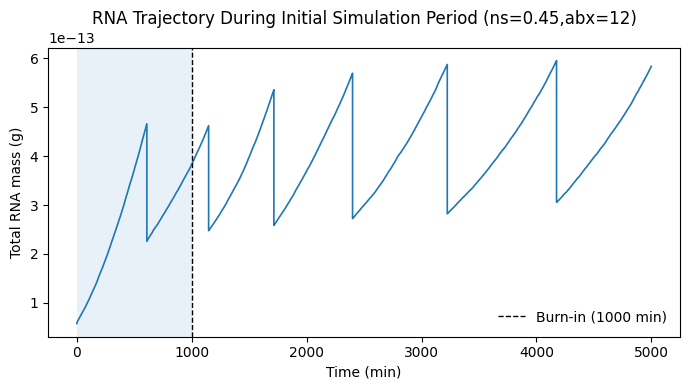

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

ARROW_FILE = "../Data/ns045/abx12.arrow"

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

MW_NT = 330.0          # g/mol
NA = 6.022e23          # Avogadro

BURN_IN = 1000         # min
TIME_LIMIT = 5000      # min

plt.style.use("default")


def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

df = load_arrow(ARROW_FILE)


def compute_rna_mass(df):

    # mRNA nucleotides
    NmRNA = (
        (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX) +
        (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX) +
        (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX) +
        (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)
    ).to_numpy()

    # total ribosome count
    Nribo = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    # rRNA nucleotides
    NrRNA = Nribo * RIBO_RNA_NT

    # total RNA mass (grams)
    RNA_mass = (NmRNA + NrRNA) / NA * MW_NT

    return RNA_mass

df["RNA_mass_g"] = compute_rna_mass(df)

df_plot = df[df["timestamp"] <= TIME_LIMIT]

plt.figure(figsize=(7,4))

plt.plot(
    df_plot["timestamp"],
    df_plot["RNA_mass_g"],
    linewidth=1.2
)

plt.axvspan(
    0,
    BURN_IN,
    alpha=0.1
)

plt.axvline(
    x=BURN_IN,
    linestyle="--",
    linewidth=1,
    color="black",
    label="Burn-in (1000 min)"
)

plt.xlabel("Time (min)")
plt.ylabel("Total RNA mass (g)")
plt.title("RNA Trajectory During Initial Simulation Period (ns=0.45,abx=12)")

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

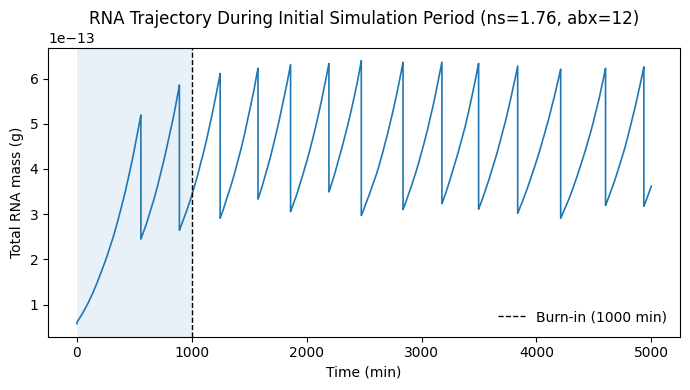

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

ARROW_FILE = "../Data/ns176/abx12.arrow"

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

MW_NT = 330.0          # g/mol
NA = 6.022e23          # Avogadro

BURN_IN = 1000         # min
TIME_LIMIT = 5000      # min

plt.style.use("default")


def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

df = load_arrow(ARROW_FILE)


def compute_rna_mass(df):

    # mRNA nucleotides
    NmRNA = (
        (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX) +
        (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX) +
        (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX) +
        (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)
    ).to_numpy()

    # total ribosome count
    Nribo = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    # rRNA nucleotides
    NrRNA = Nribo * RIBO_RNA_NT

    # total RNA mass (grams)
    RNA_mass = (NmRNA + NrRNA) / NA * MW_NT

    return RNA_mass

df["RNA_mass_g"] = compute_rna_mass(df)

df_plot = df[df["timestamp"] <= TIME_LIMIT]

plt.figure(figsize=(7,4))

plt.plot(
    df_plot["timestamp"],
    df_plot["RNA_mass_g"],
    linewidth=1.2
)

plt.axvspan(
    0,
    BURN_IN,
    alpha=0.1
)

plt.axvline(
    x=BURN_IN,
    linestyle="--",
    linewidth=1,
    color="black",
    label="Burn-in (1000 min)"
)

plt.xlabel("Time (min)")
plt.ylabel("Total RNA mass (g)")
plt.title("RNA Trajectory During Initial Simulation Period (ns=1.76, abx=12)")

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()